# Pregunta 2

#### 1. Datos y ruido reproducible

La imagen se normaliza a `[0,1]` y se agrega ruido gaussiano de media cero y desviacion estandar `0.05`

Tamano: (256, 256); RMSE ruidosa: 0.04791


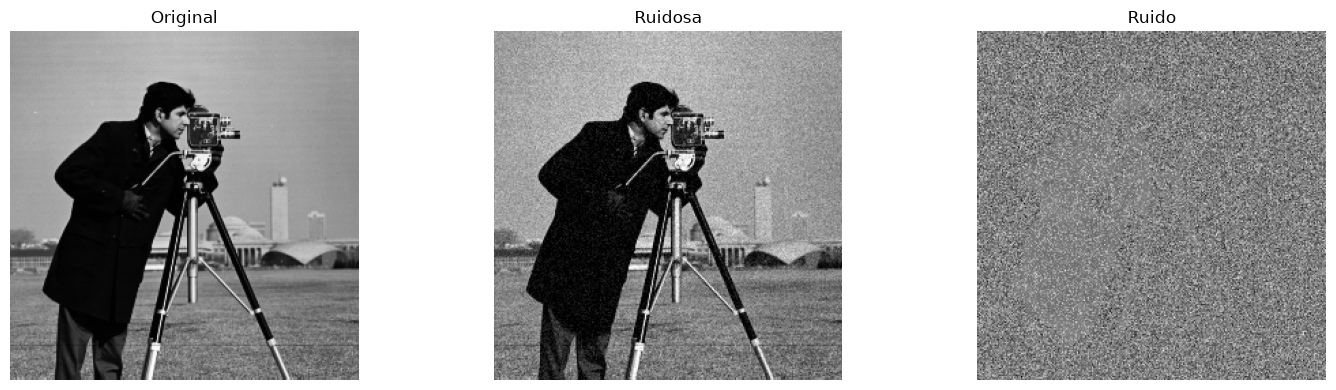

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

SEED = 2026
NOISE_STD = 0.05
IMAGE_PATH = Path("cameraman.tif")
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"No se encontro {IMAGE_PATH.resolve()}")
original = np.asarray(Image.open(IMAGE_PATH).convert("L"), dtype=np.float64)
original = (original - original.min()) / (original.max() - original.min())
rng = np.random.default_rng(SEED)
noisy = np.clip(original + rng.normal(0, NOISE_STD, original.shape), 0, 1)
def rmse(a, b): return float(np.sqrt(np.mean((a-b)**2)))
print(f"Tamano: {original.shape}; RMSE ruidosa: {rmse(noisy, original):.5f}")
fig, ax = plt.subplots(1,3,figsize=(15,4))
for a, im, title in zip(ax,[original,noisy,noisy-original],["Original","Ruidosa","Ruido"]):
    a.imshow(im,cmap="gray",vmin=0 if title!="Ruido" else -.2,vmax=1 if title!="Ruido" else .2); a.set_title(title); a.axis("off")
plt.tight_layout()


#### 2. Implementacion: infraestructura comun

Se usa `u^(n+1)=u^n+lambda div(c grad u)`. Los flujos se calculan en las cuatro caras con el promedio de `c` entre pixeles vecinos. Para `c >= 0`, se usa el criterio conservador `lambda <= 1/(4 max(c))`.

In [2]:
def gradients(u):
    p=np.pad(u,1,mode="edge")
    return .5*(p[1:-1,2:]-p[1:-1,:-2]), .5*(p[2:,1:-1]-p[:-2,1:-1])
def laplacian(u):
    p=np.pad(u,1,mode="edge")
    return p[1:-1,2:]+p[1:-1,:-2]+p[2:,1:-1]+p[:-2,1:-1]-4*u
def local_variance(u):
    p=np.pad(u,1,mode="edge")
    mean=sum(p[i:i+u.shape[0],j:j+u.shape[1]] for i in range(3) for j in range(3))/9
    mean2=sum(p[i:i+u.shape[0],j:j+u.shape[1]]**2 for i in range(3) for j in range(3))/9
    return np.maximum(mean2-mean**2,0)
def diffuse(u0, coefficient, lam, iterations, auto_stable=True):
    u=np.asarray(u0,dtype=float).copy(); c=coefficient(u)
    if np.any(c<0) or not np.all(np.isfinite(c)): raise ValueError("c debe ser finito y no negativo")
    stable=1/(4*max(float(c.max()),np.finfo(float).eps)); used=min(lam,stable) if auto_stable else lam
    for _ in range(iterations):
        c=coefficient(u); p=np.pad(u,1,mode="edge"); cp=np.pad(c,1,mode="edge")
        east=.5*(c+cp[1:-1,2:])*(p[1:-1,2:]-u); west=.5*(c+cp[1:-1,:-2])*(p[1:-1,:-2]-u)
        south=.5*(c+cp[2:,1:-1])*(p[2:,1:-1]-u); north=.5*(c+cp[:-2,1:-1])*(p[:-2,1:-1]-u)
        u=np.clip(u+used*(east+west+south+north),0,1)
    return u, coefficient(u), used, stable
def tv_coefficient(eps):
    def c(u):
        gx,gy=gradients(u); return 1/np.sqrt(gx*gx+gy*gy+eps*eps)
    return c
def laplacian_coefficient(k_grad=.10,lap_weight=1.,lap_scale=.10):
    def c(u):
        gx,gy=gradients(u); g=np.hypot(gx,gy); lap=np.abs(laplacian(u))
        E=(g/k_grad)**2+lap_weight*lap/(lap_scale+1e-12); return 1/(1+E)
    return c
def texture_coefficient(k_grad=.12,k_var=.025,texture_weight=2.):
    def c(u):
        gx,gy=gradients(u); var=local_variance(u)
        E=(gx*gx+gy*gy)/k_grad**2+texture_weight*var/(k_var+1e-12); return .10+.90/(1+E)
    return c
def run(name, coefficient, lam=.20, iterations=100, auto=True):
    out,c,used,stable=diffuse(noisy,coefficient,lam,iterations,auto)
    return dict(name=name,result=out,cmap=c,rmse=rmse(out,original),used=used,stable=stable)
print("Infraestructura lista")


Infraestructura lista


#### 3. TV: sensibilidad de epsilon

`epsilon` controla el maximo de `cTV`. Un valor pequeno produce difusion muy intensa en zonas planas y un contraste mayor entre zonas planas y bordes. Uno grande reduce esa diferencia y vuelve el suavizado ms uniforme.


TV eps=0.005 lambda= 0.00125 RMSE= 0.06294
TV eps=0.02 lambda= 0.00500 RMSE= 0.09647
TV eps=0.08 lambda= 0.02000 RMSE= 0.11967
TV eps=0.2 lambda= 0.05000 RMSE= 0.12253


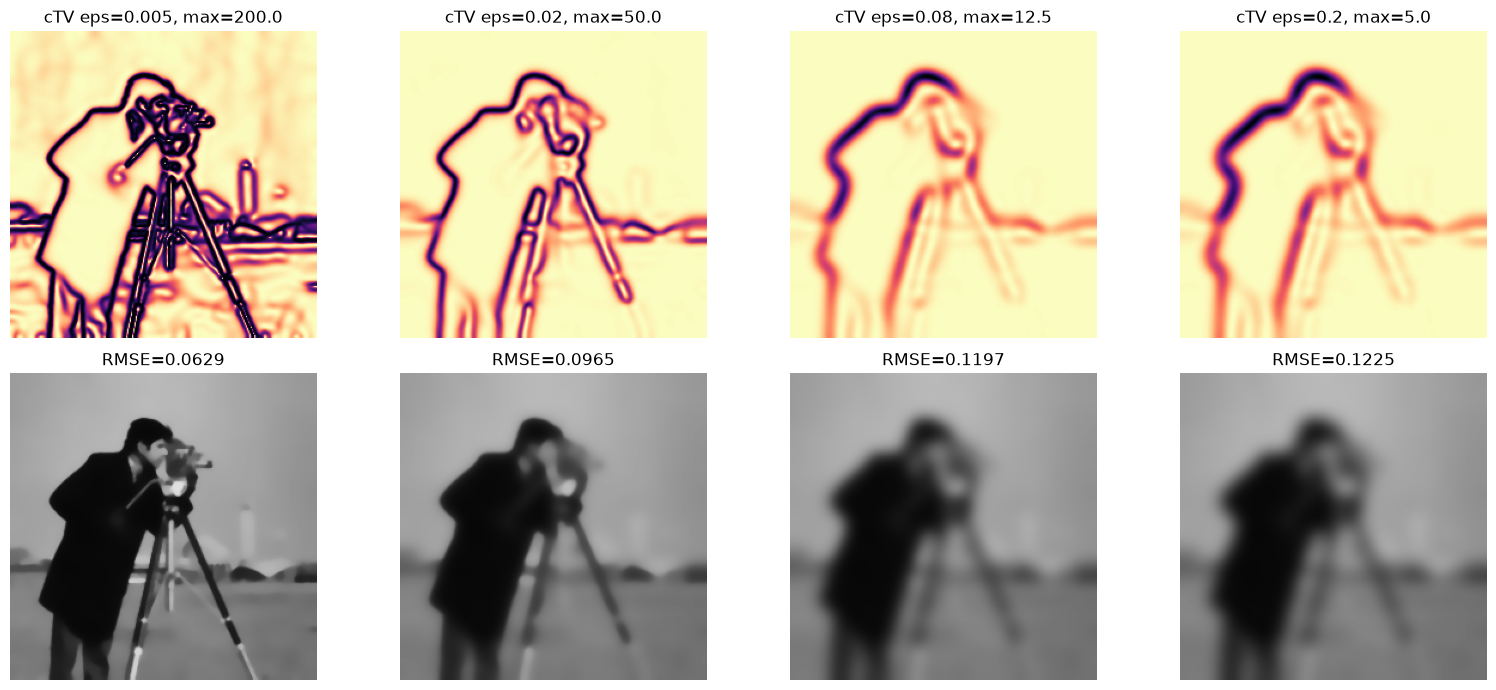

In [3]:
eps_values=[.005,.02,.08,.20]
tv_results=[run(f"TV eps={e}",tv_coefficient(e)) for e in eps_values]
fig,ax=plt.subplots(2,4,figsize=(16,7))
for j,(e,r) in enumerate(zip(eps_values,tv_results)):
    ax[0,j].imshow(r["cmap"],cmap="magma"); ax[0,j].set_title(f"cTV eps={e}, max={r['cmap'].max():.1f}")
    ax[1,j].imshow(r["result"],cmap="gray",vmin=0,vmax=1); ax[1,j].set_title(f"RMSE={r['rmse']:.4f}")
    ax[0,j].axis("off"); ax[1,j].axis("off")
plt.tight_layout()
for r in tv_results: print(r["name"],"lambda=",f"{r['used']:.5f}","RMSE=",f"{r['rmse']:.5f}")


#### 4. Efecto conjunto de epsilon, lambda e iteraciones

Se comparan una evolucion lenta, una eleccion razonable, un sobre-suavizado y un caso inestable. En el ultimo se desactiva la correccion automatica para mostrar la necesidad del criterio de estabilidad.

Lento: lambda usado=0.01000, estable=0.02000, RMSE=0.05264, rango=[0.010,0.931]
Razonable: lambda usado=0.02000, estable=0.02000, RMSE=0.11483, rango=[0.027,0.727]
Sobre-suavizado: lambda usado=0.05000, estable=0.05000, RMSE=0.14414, rango=[0.038,0.720]
Inestable: lambda usado=0.20000, estable=0.00125, RMSE=0.56090, rango=[0.000,1.000]


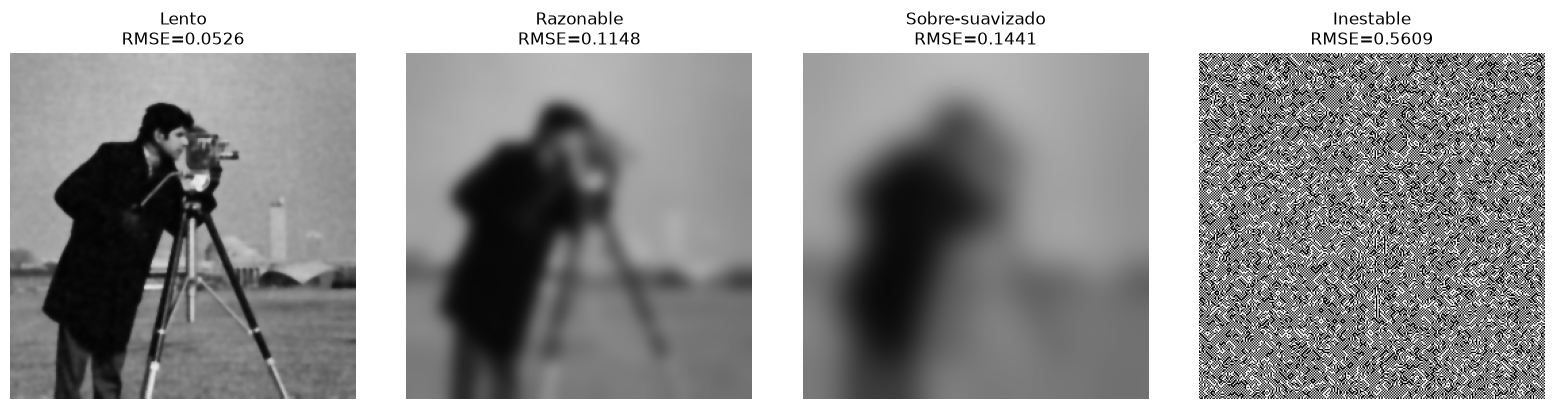

In [4]:
cases=[("Lento",tv_coefficient(.08),.01,10,True),("Razonable",tv_coefficient(.08),.20,80,True),("Sobre-suavizado",tv_coefficient(.20),.20,350,True),("Inestable",tv_coefficient(.005),.20,40,False)]
joint=[]
for name,c,lam,n,auto in cases:
    r=run(name,c,lam,n,auto); joint.append(r)
    print(f"{name}: lambda usado={r['used']:.5f}, estable={r['stable']:.5f}, RMSE={r['rmse']:.5f}, rango=[{r['result'].min():.3f},{r['result'].max():.3f}]")
fig,ax=plt.subplots(1,4,figsize=(16,4))
for a,r in zip(ax,joint): a.imshow(r["result"],cmap="gray",vmin=0,vmax=1); a.set_title(r["name"]+f"\nRMSE={r['rmse']:.4f}"); a.axis("off")
plt.tight_layout()


#### 5. Coeficientes alternativos

**A: gradiente + Laplaciano:** `E=(|grad u|/k_g)^2 + alpha |Delta u|/k_l`, `c=1/(1+E)`. El Laplaciano protege cambios de curvatura, pero amplifica ruido.

**B: gradiente + textura:** `E=|grad u|^2/k_g^2 + beta Var_3x3(u)/k_v`, `c=.10+.90/(1+E)`. La varianza reduce difusion en textura y el piso `.10` mantiene difusion minima.


Lap A
Lap A (0.06, 0.5, 0.08) RMSE= 0.08971 max(c)= 1.0000
Lap A (0.1, 1.0, 0.1) RMSE= 0.10475 max(c)= 1.0000
Lap A (0.18, 2.0, 0.15) RMSE= 0.11283 max(c)= 1.0000
Textura B
Textura B (0.08, 0.015, 1.0) RMSE= 0.10779 max(c)= 1.0000
Textura B (0.12, 0.025, 2.0) RMSE= 0.11180 max(c)= 1.0000
Textura B (0.2, 0.05, 4.0) RMSE= 0.11433 max(c)= 1.0000


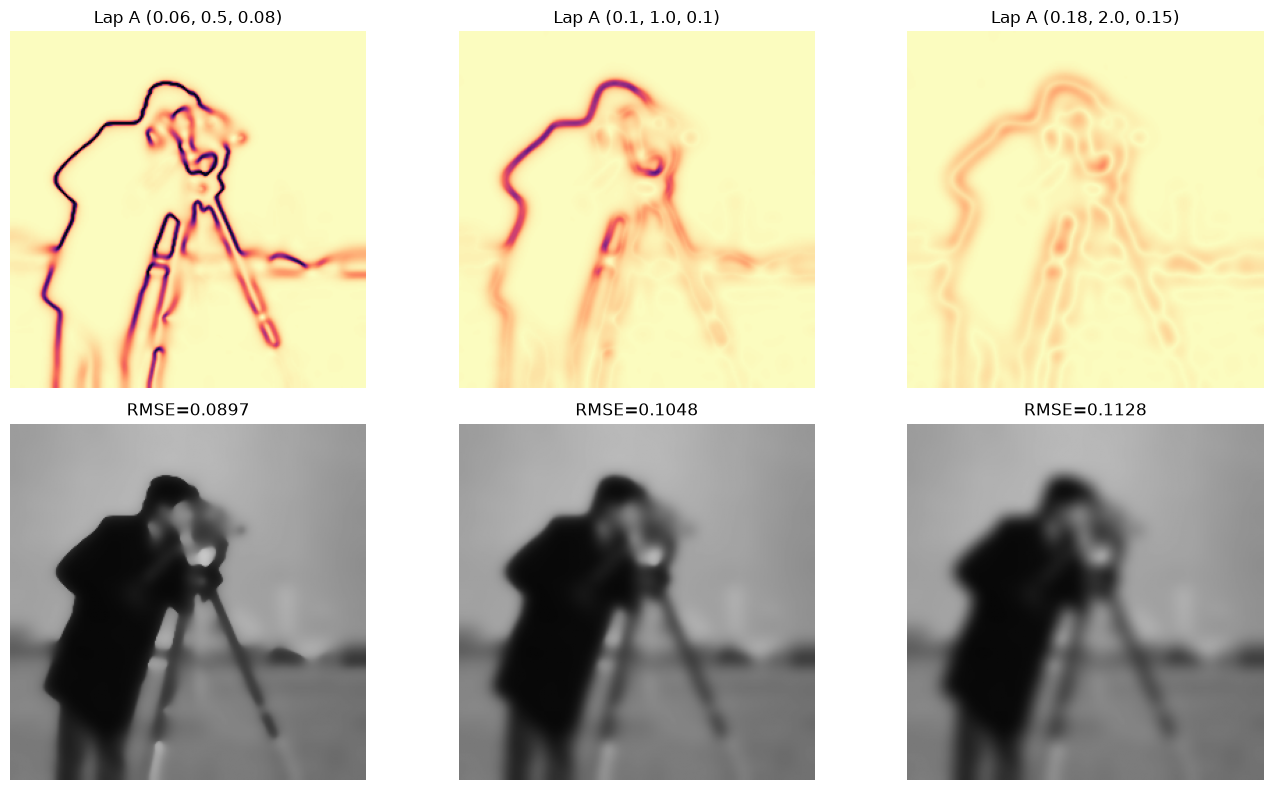

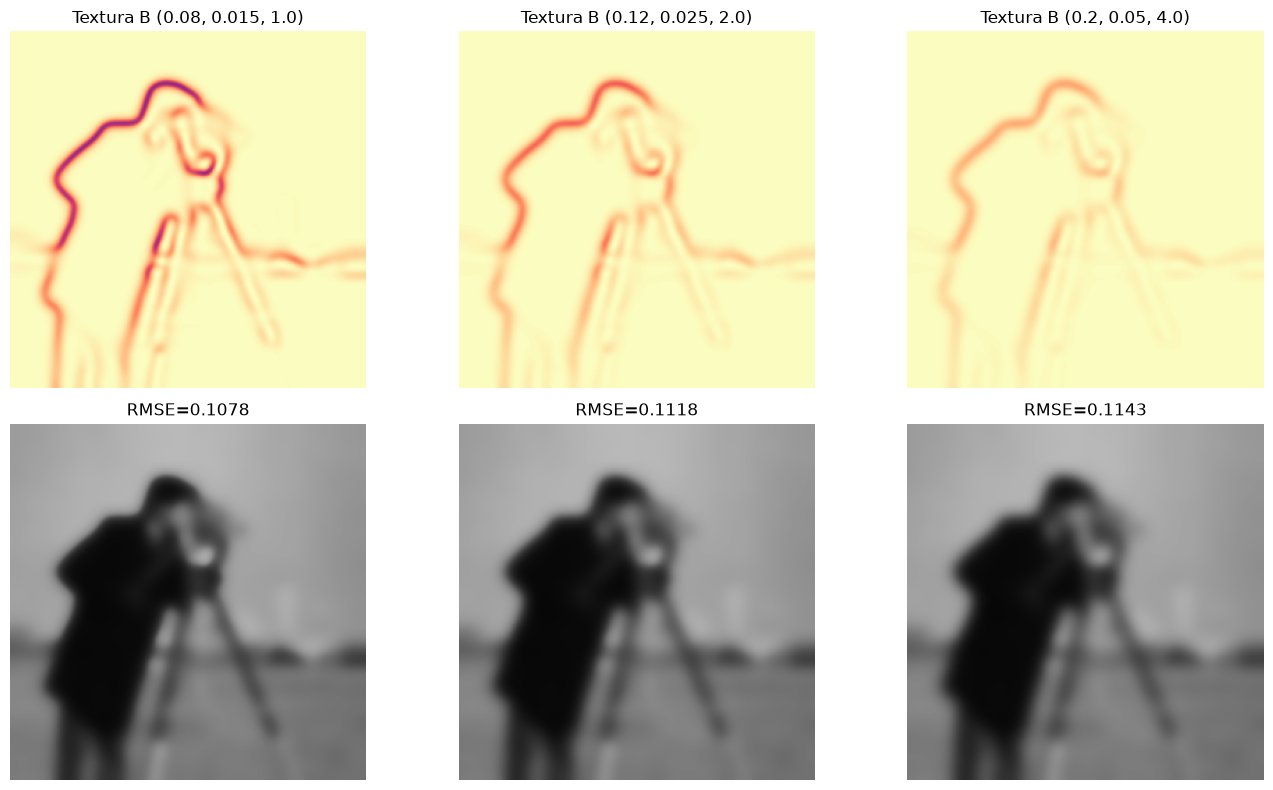

In [5]:
lap_params=[(.06,.5,.08),(.10,1.,.10),(.18,2.,.15)]
tex_params=[(.08,.015,1.),(.12,.025,2.),(.20,.050,4.)]
lap_results=[run(f"Lap A {p}",laplacian_coefficient(*p)) for p in lap_params]
tex_results=[run(f"Textura B {p}",texture_coefficient(*p)) for p in tex_params]
for title,results,params in [("Lap A",lap_results,lap_params),("Textura B",tex_results,tex_params)]:
    fig,ax=plt.subplots(2,3,figsize=(14,8))
    for j,r in enumerate(results):
        ax[0,j].imshow(r["cmap"],cmap="magma",vmin=0,vmax=1); ax[0,j].set_title(f"{title} {params[j]}")
        ax[1,j].imshow(r["result"],cmap="gray",vmin=0,vmax=1); ax[1,j].set_title(f"RMSE={r['rmse']:.4f}")
        ax[0,j].axis("off"); ax[1,j].axis("off")
    plt.tight_layout()
    print(title)
    for r in results: print(r["name"],"RMSE=",f"{r['rmse']:.5f}","max(c)=",f"{r['cmap'].max():.4f}")


### Sensibilidad del Laplaciano al ruido

El segundo derivado amplifica variaciones rapidas. Por eso se comparan sus magnitudes y mapas sobre la imagen original y la ruidosa, usando los mismos parametros.


Mediana |Laplaciano|: 0.02846 -> 0.16236
Percentil 95: 0.43191 -> 0.57121


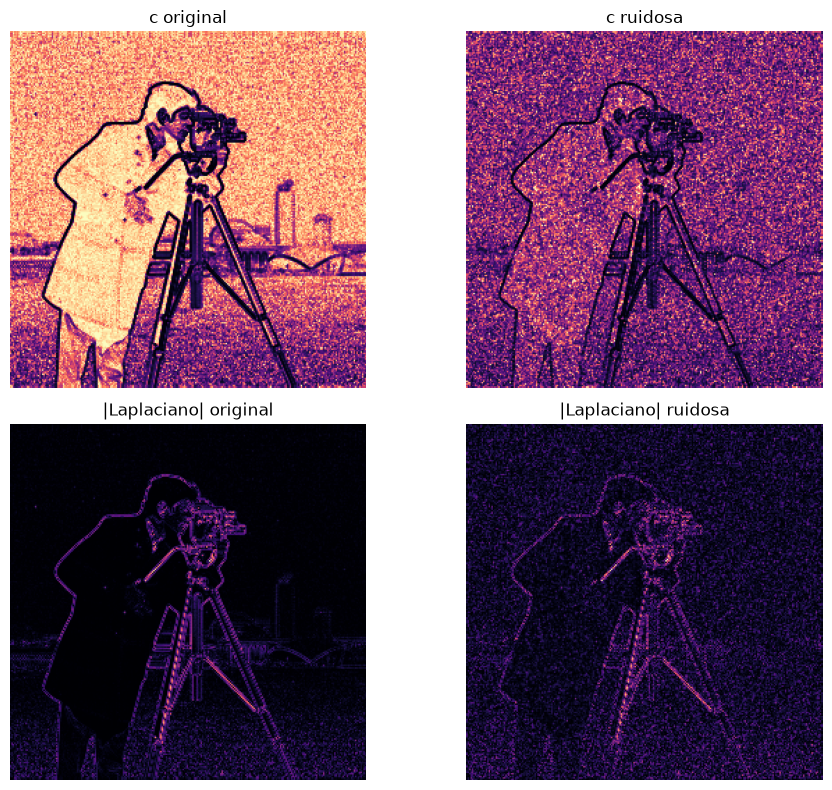

In [6]:
coef=laplacian_coefficient(.10,1.,.10)
c0,c1=coef(original),coef(noisy)
l0,l1=np.abs(laplacian(original)),np.abs(laplacian(noisy))
print("Mediana |Laplaciano|:",f"{np.median(l0):.5f}","->",f"{np.median(l1):.5f}")
print("Percentil 95:",f"{np.percentile(l0,95):.5f}","->",f"{np.percentile(l1,95):.5f}")
fig,ax=plt.subplots(2,2,figsize=(10,8))
for a,im,t in zip(ax.ravel(),[c0,c1,l0,l1],["c original","c ruidosa","|Laplaciano| original","|Laplaciano| ruidosa"]): a.imshow(im,cmap="magma"); a.set_title(t); a.axis("off")
plt.tight_layout()

#### 6. Comparaciones finales

RMSE ruidosa: 0.04791
TV eps=.08 RMSE=0.06843
Lap A RMSE=0.03860
Textura B RMSE=0.05533


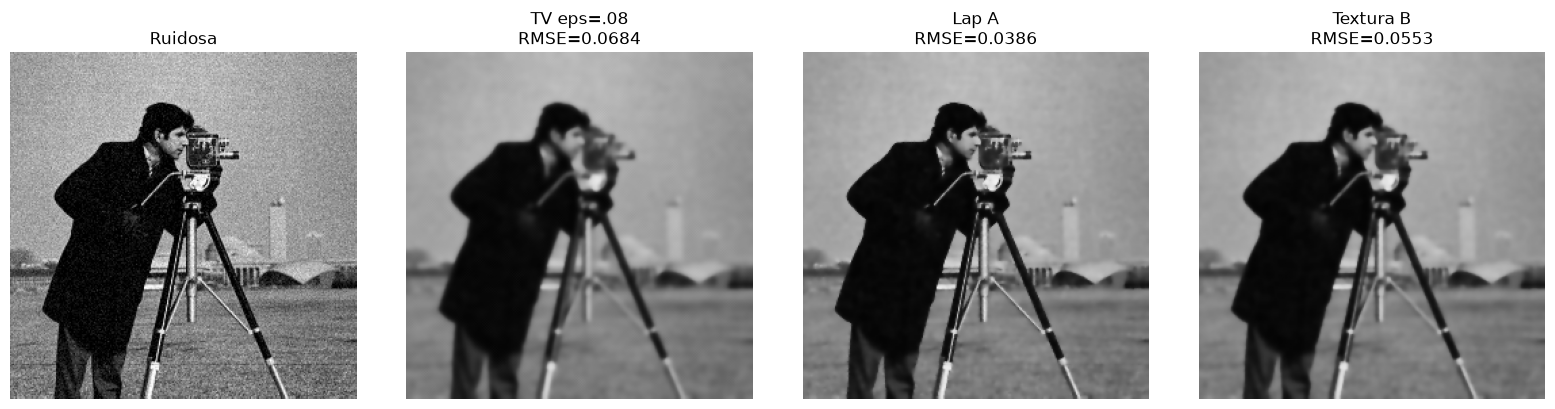

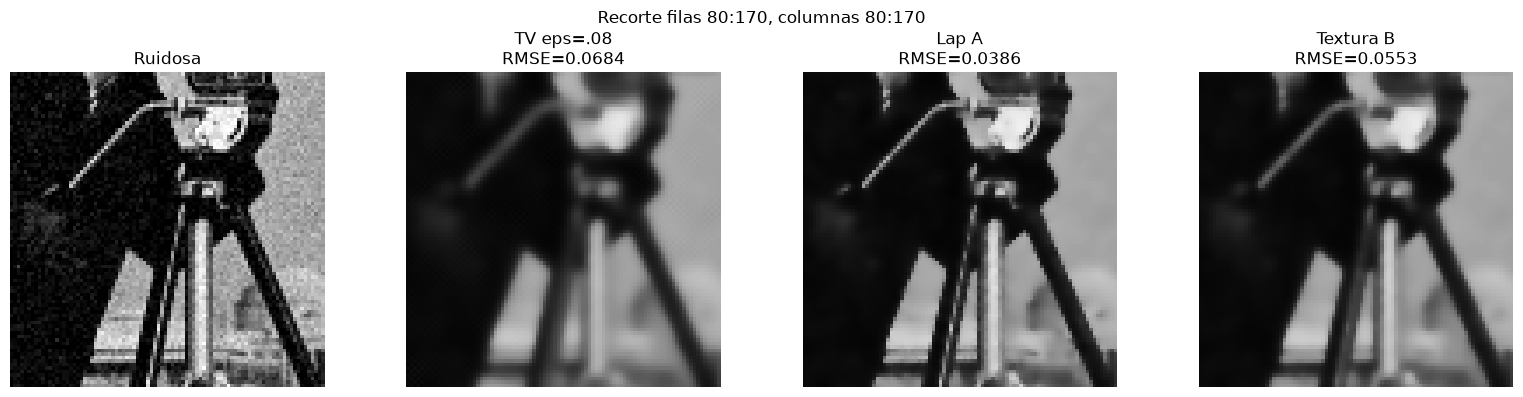

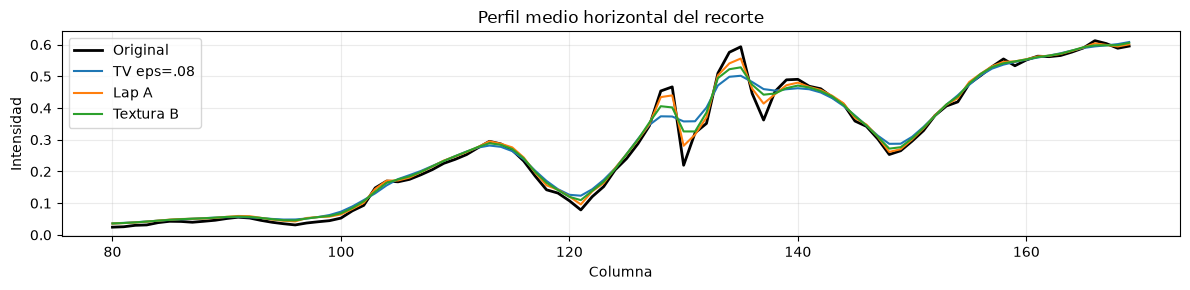

In [7]:
final=[run("TV eps=.08",tv_coefficient(.08),iterations=10),run("Lap A",laplacian_coefficient(.10,1.,.10),iterations=10),run("Textura B",texture_coefficient(.12,.025,2.),iterations=10)]
print("RMSE ruidosa:",f"{rmse(noisy,original):.5f}")
for r in final: print(r["name"],f"RMSE={r['rmse']:.5f}")
images=[noisy]+[r["result"] for r in final]; titles=["Ruidosa"]+[r["name"]+f"\nRMSE={r['rmse']:.4f}" for r in final]
fig,ax=plt.subplots(1,4,figsize=(16,4))
for a,im,t in zip(ax,images,titles): a.imshow(im,cmap="gray",vmin=0,vmax=1); a.set_title(t); a.axis("off")
plt.tight_layout()
r0,r1,c0,c1=80,170,80,170
fig,ax=plt.subplots(1,4,figsize=(16,4))
for a,im,t in zip(ax,images,titles): a.imshow(im[r0:r1,c0:c1],cmap="gray",vmin=0,vmax=1,interpolation="nearest"); a.set_title(t); a.axis("off")
plt.suptitle(f"Recorte filas {r0}:{r1}, columnas {c0}:{c1}"); plt.tight_layout()
x=np.arange(c0,c1); fig,ax=plt.subplots(figsize=(12,3)); ax.plot(x,original[r0:r1,c0:c1].mean(0),"k",lw=2,label="Original")
for r in final: ax.plot(x,r["result"][r0:r1,c0:c1].mean(0),label=r["name"])
ax.set_title("Perfil medio horizontal del recorte"); ax.set_xlabel("Columna"); ax.set_ylabel("Intensidad"); ax.grid(alpha=.25); ax.legend(); plt.tight_layout()
